# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [7]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Santiago Perez Sandi Castellanos"
MATRICULA = "81869"
DATASET_ASIGNADO = "pib"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Santiago Perez Sandi Castellanos
Matrícula: 81869
Dataset asignado: pib


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [8]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\santi\OneDrive\Escritorio\bigdata\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [10]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
#metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [26]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [12]:
# Forma del dataset (filas, columnas)
df.shape


(12384, 4)

In [13]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB


In [14]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64

In [15]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?
analizando los datos me doy cuenta que realmente no tengo valores nulos en este dataset, si no me equivoco el tipo de variable con la que voy a trabajar es un float debido a que los datos estan guardados con decimales, igualmente mi rango de años que logro ver es de 25 es decir del 2000 al 2024


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [39]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull()]

cantidad_paises = df_paises["entity"].nunique()
print("Cantidad paises: ", cantidad_paises)

top_mayor = (df_paises.groupby("entity")["valor"].max().reset_index().sort_values(by="valor", ascending=False))
print("Paises con mayor valor: ", top_mayor.head(10))

top_menor = (df_paises.groupby("entity")["valor"].min().reset_index().sort_values(by="valor", ascending=True))
print("Paises con mayor valor: ", top_menor.head(10))



Cantidad paises:  226
Paises con mayor valor:                     entity       valor
135                Monaco  247170.110
116         Liechtenstein  167187.160
21                Bermuda  132595.480
212  United Arab Emirates  117073.350
120            Luxembourg  112422.150
96                Ireland  104416.836
121                 Macao   99054.500
27                 Brunei   96517.130
35         Cayman Islands   96202.734
97            Isle of Man   95110.140
Paises con mayor valor:             entity      valor
140       Myanmar  122.67890
40          China  166.08516
139    Mozambique  169.78780
88       Honduras  179.89351
169        Rwanda  187.38014
65       Ethiopia  207.96788
186       Somalia  210.44620
30        Burundi  212.34285
114       Liberia  216.09355
29   Burkina Faso  244.16725


**Interpretación:**

pues no se mucho, pero supongo que los paises con mayor valor muestran paises donde la economia probablemente sea muy cara, en cambio en los paises con menos valor, pues paises donde la economia sea mas amigable.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [43]:
# Pregunta 2
pais_1 = "Mexico"
pais_2 = "United Kingdom"

años_p1 = df_paises[df_paises["entity"] == pais_1]["year"]
años_p2 = df_paises[df_paises["entity"] == pais_2]["year"]

año_inicio = max(años_p1.min(), años_p2.min())
año_fin = min(años_p1.max(), años_p2.max())

df_paises = df_paises[
    (df_paises["entity"].isin([pais_1, pais_2])) & 
    (df_paises["year"].between(año_inicio, año_fin))
]

df_paises



,entity,code,year,valor
7225,Mexico,MEX,1960,4145.7930
7226,Mexico,MEX,1961,4219.1816
7227,Mexico,MEX,1962,4276.1430
7228,Mexico,MEX,1963,4474.7275
7229,Mexico,MEX,1964,4845.8745
...,...,...,...,...
11739,United Kingdom,GBR,2021,46491.5080
11740,United Kingdom,GBR,2022,48410.0940
11741,United Kingdom,GBR,2023,47911.1520
11742,United Kingdom,GBR,2024,47900.9700


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [48]:
# Pregunta 3
paises_seleccionados = [
    "Mexico",          
    "Japan",           
    "United Kingdom",  
    "Nigeria",         
    "Australia"        
]
columna_indicador = "valor"
ultimo_año = df["year"].max()

df_pregunta_3 = df[
    (df["entity"].isin(paises_seleccionados)) & 
    (df["year"] == ultimo_año)
]

pais_max = df_pregunta_3.loc[df_pregunta_3[columna_indicador].idxmax()]
pais_min = df_pregunta_3.loc[df_pregunta_3[columna_indicador].idxmin()]
diferencia = pais_max[columna_indicador] - pais_min[columna_indicador]

print(f"Más alto: {pais_max['entity']} con {pais_max[columna_indicador]:.2f}")
print(f"Más bajo: {pais_min['entity']} con {pais_min[columna_indicador]:.2f}")
print(f"Diferencia: {diferencia:.2f}")


Más alto: Australia con 61368.61
Más bajo: Nigeria con 2368.54
Diferencia: 59000.07


**Interpretación:**

puedo interpretar de ver solo los datos con mi nulo conocimiento sobre el mundo, que nigeria es un lugar sin mucho dinero en cambio australia que muestra el valor maximo, es un pais con una cantidad de dinero mas grande, por eso el valor del pib es mas alto 

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [50]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

columna_indicador = "valor"

ultimo_año = df["year"].max()

df_latam = df[(df["entity"].isin(latinoamerica)) & (df["year"] == ultimo_año)]
df_asia = df[(df["entity"].isin(asia)) & (df["year"] == ultimo_año)]

promedio_latam = df_latam[columna_indicador].mean()
promedio_asia = df_asia[columna_indicador].mean()

print(f"Promedio Latinoamérica: {promedio_latam:.2f}")
print(f"Promedio Asia: {promedio_asia:.2f}")


Promedio Latinoamérica: 10173.12
Promedio Asia: 18906.92


**Interpretación:**

yo creo pensando en que asia basicamente tiene mas valor de pib comparado con mexico debido a que supongo por logica tienen un desarrollo economico mas alto comparado con mexico lo cual lleva a un valor de pib mas alto, asia tiene casi el doble de valor a mexico.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

Año con valor MÁXIMO: 2018 con un valor de 10296.87
Año con valor MÍNIMO: 1960 con un valor de 4145.79


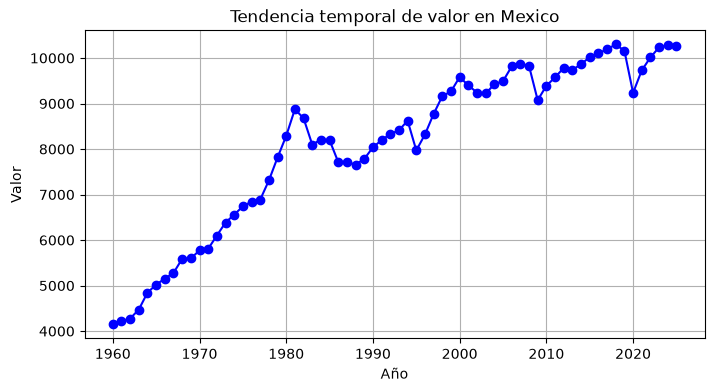

In [52]:
# Pregunta 5
pais_elegido = "Mexico"
columna_indicador = "valor"

df_pais = df[df["entity"] == pais_elegido].sort_values("year")

fila_max = df_pais.loc[df_pais[columna_indicador].idxmax()]
fila_min = df_pais.loc[df_pais[columna_indicador].idxmin()]

print(f"Año con valor MÁXIMO: {int(fila_max['year'])} con un valor de {fila_max[columna_indicador]:.2f}")
print(f"Año con valor MÍNIMO: {int(fila_min['year'])} con un valor de {fila_min[columna_indicador]:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(df_pais["year"], df_pais[columna_indicador], marker='o', color='b', linewidth=1.5)
plt.title(f"Tendencia temporal de {columna_indicador} en {pais_elegido}")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.grid(True)
plt.show()


**Interpretación:**

diria que la tendencia es creciente,tambien por los 1985 masomenos se muestra una caida, al igual que por los 1995, 2008 y 2020 , todos años donde supongo por logica paso algo que creo una crisis economica.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [54]:
# Pregunta 6
df_mexico = df[df["entity"] == "Mexico"].sort_values("year")

valor_inicial = df_mexico.iloc[0]["valor"]
año_inicial = df_mexico.iloc[0]["year"]

valor_final = df_mexico.iloc[-1]["valor"]
año_final = df_mexico.iloc[-1]["year"]

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print(f"Año inicial ({int(año_inicial)}): {valor_inicial:.2f}")
print(f"Año final ({int(año_final)}): {valor_final:.2f}")
print(f"Cambio Porcentual: {cambio_porcentual:.2f}%")


Año inicial (1960): 4145.79
Año final (2025): 10256.69
Cambio Porcentual: 147.40%


**Interpretación:**

si se muestra un cambio muy significativo con ese 147% de cambio entre uno y otro, muestra como la economia ah cambiado con todo lo que ah ido pasando a lo largo de los años avances tecnologicos, etc.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [56]:
# Pregunta 7
ultimo_año = df["year"].max()

df_paises_reales = df[(df["code"].notnull()) & (df["year"] == ultimo_año)]

valores = df_paises_reales["valor"].to_numpy()

valores_limpios = valores[~np.isnan(valores)]

media = np.mean(valores_limpios)
mediana = np.median(valores_limpios)
desviacion_estandar = np.std(valores_limpios)

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desviacion_estandar:.2f}")


Media: 15459.02
Mediana: 6782.75
Desviación estándar: 20190.97


**Interpretación:**

entre la media y la mediana, hay mucha diferencia entre cada uno, al igual que la desviacion estandar es notablemente mas grande que la media, lo cual siento es que hay mucha variabilidad entre todos los paises.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

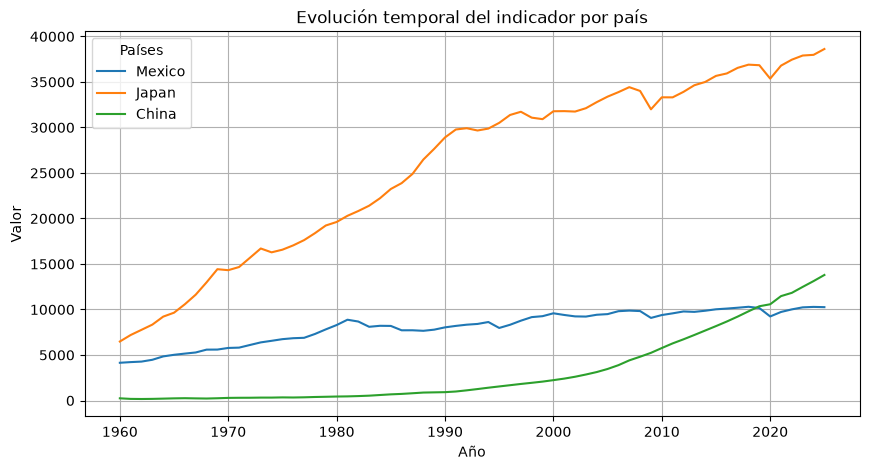

In [57]:
# Pregunta 8
import matplotlib.pyplot as plt

paises = ["Mexico", "Japan", "China"]

plt.figure(figsize=(10, 5))

for pais in paises:
    df_sub = df[df["entity"] == pais].sort_values("year")
    plt.plot(df_sub["year"], df_sub["valor"], label=pais)

plt.title("Evolución temporal del indicador por país")
plt.xlabel("Año")
plt.ylabel("Valor")
plt.legend(title="Países")
plt.grid(True)

plt.show()


**Interpretación:**

la grafica muestra como japon tiene un valor de pib muchisimo mas alto que mexico y china, al igual que muestra como mexico siento se ah mantenido y ah ido subieneo de forma muy lenta atravez de los años, en cambio japon en los 2000 empezo a tener un crecimiento muy rapido, viendo sus valores de casi 0 por mucho tiempo y viendo como en los 1990 empieza a subir y justamente llegando por los 2000 empieza a dispararse para arriba sin casi ningun indice de bajar pronto.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

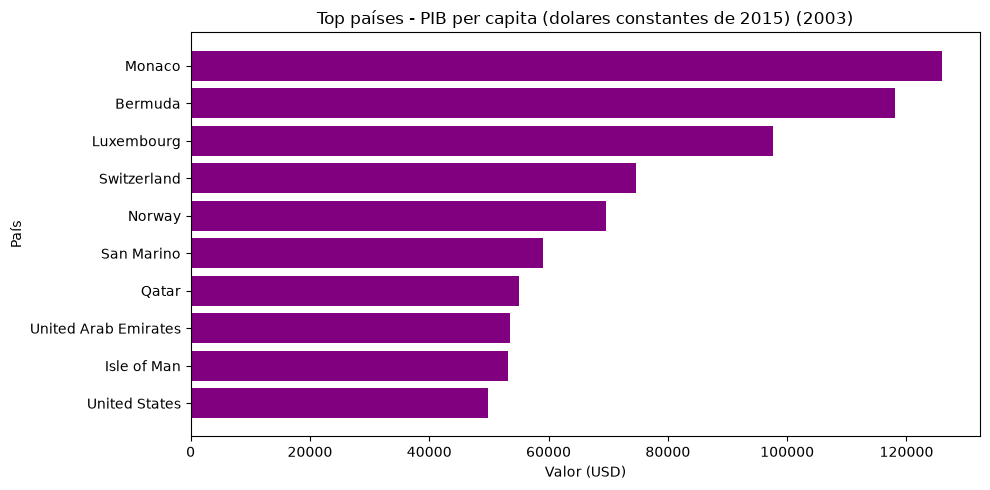

In [ ]:
# Pregunta 9 - 1
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2003

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='purple')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


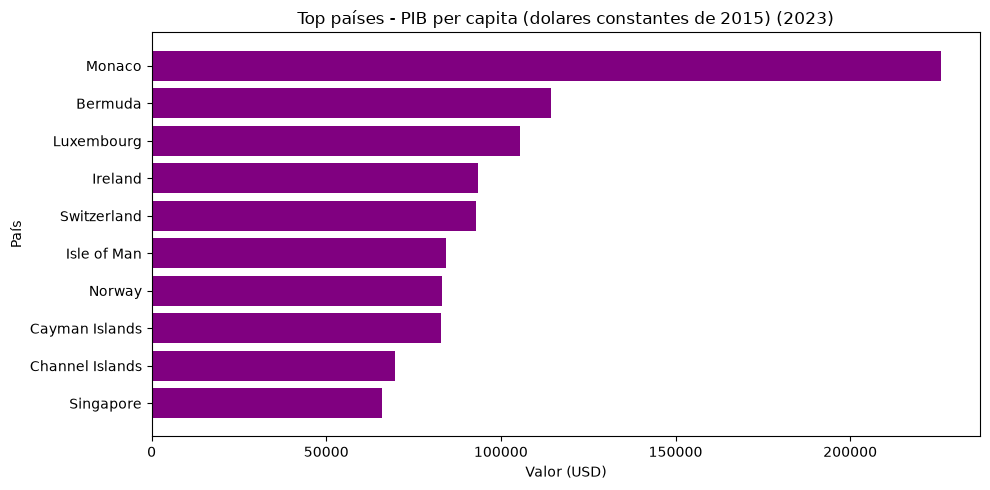

In [63]:
# Pregunta 9 - 2
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2023

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='purple')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

note principalmente que los paises de arriba se mantuvieron en su puesto, pero por ejemplo monaco subio casi el doble de su valor, de 120k aprox a mas de 200k, mientras los demas se mantuvieron con valores muy similares manteniendose casi iguales.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

para empezar si tuviera mas tiempo me tomaria el tiempo para buscar mas datos sobre muchos mas paises, pero lo principal que note es que los paises especialmente los de japon son muy altos comparados a otros, los paises que tienen mas avanzes de todo tipo tienen un valor de pib mucho mas alto de los que no, no encontre ningun valor nulo en este dataset lo cual la verdad me sorprendio, crei si iba a ver varios, pero eso principalmente encontre los patrones de paises mas avanzados teniendo mas valor de pib, por razones muy logicas, pero pues obviamente hay una tendendia de crecimiento desde 1960 a 2023, eso seria lo principal.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
